In [1]:
import numpy as np 
import importlib
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from scipy.integrate import simpson
from pycorr import TwoPointEstimator

import src.statistics.inference as inference
import src.statistics.combination as comb
import src.statistics.cosmotools as ct
import src.statistics.corrfiles as cf
import src.statistics.sgp as sgp

In [2]:
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

In [3]:
stem = 'dr2'
path_dictionary = {
    'HSC' : ROOT / 'v12_correction' / f'autos_HSC', # with no wpp correction, is unused
    'DESI_NGC' : ROOT / stem / f'autos_NGC',
    'DESI_SGC' : ROOT / stem / f'autos_SGC',
    'DESIxHSC' : ROOT / stem / f'cross',
}
assert all([p.exists() for p in path_dictionary.values()])
outdir = ROOT / f'merged_{stem}'

In [4]:
importlib.reload(inference)
importlib.reload(comb)
importlib.reload(ct)
importlib.reload(cf)
tracer = 'ELGnotqso'  # 'BGS_ANY', 'LRG', 'ELGnotqso', 'QSO'
tomo = 3
scale_cut = [.2, 2]
fr = cf.CorrFileReader(path_dictionary['DESIxHSC'])
zbins = fr.get_bins(tracer)
meas = inference.full_npz_tomo(
    path_dictionary=path_dictionary,
    do_bias_correction=True,
    scale_cuts=scale_cut,
    tomo_bin=tomo,
    tracer=tracer,
    which_patches=[1,2,3,4]
)
zvals = (zbins[:-1] + zbins[1:]) / 2

Using standard method for tracer ELGnotqso and tomo bin 3.


In [5]:
importlib.reload(ct)
npz, npz_err, wdm, Mag, dMag = ct.solve_magnification(
    meas=meas,
    tracer=tracer,
    tomo_bin=tomo,
    scale_cut=scale_cut,
    zvalues=zvals,
    return_matrices=True
)

Computing w_dm for 18 redshifts and 101 rp values...
Computing magnification matrix for 18 redshifts...
Solving the linear system for 18 redshifts...
Computing magnification matrix for 18 redshifts...
Solving the linear system for 18 redshifts...


Text(0.5, 1.0, 'ELGnotqso - [0.2 < r < 2] h^-1 Mpc')

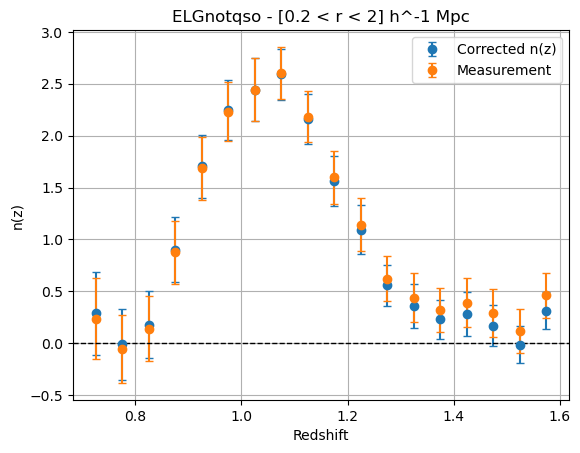

In [6]:
plt.errorbar(zvals, npz, yerr=npz_err, fmt='o', color='C0', label='Corrected n(z)', capsize=3)
plt.errorbar(zvals, meas[0], yerr=meas[1], fmt='o', color='C1', label='Measurement', capsize=3)
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.grid()
plt.xlabel('Redshift')
plt.ylabel('n(z)')
plt.legend()
plt.title(f'{tracer} - [{scale_cut[0]} < r < {scale_cut[1]}] h^-1 Mpc')

Using standard method for tracer LRG and tomo bin 3.
Computing w_dm for 18 redshifts and 101 rp values...
Computing w_dm for 18 redshifts and 101 rp values...
Computing magnification matrix for 18 redshifts...
Solving the linear system for 18 redshifts...
Using standard method for tracer ELGnotqso and tomo bin 3.
Computing magnification matrix for 18 redshifts...
Solving the linear system for 18 redshifts...
Using standard method for tracer ELGnotqso and tomo bin 3.
Computing w_dm for 18 redshifts and 101 rp values...
Computing w_dm for 18 redshifts and 101 rp values...
Computing magnification matrix for 18 redshifts...
Solving the linear system for 18 redshifts...
Using standard method for tracer QSO and tomo bin 3.
Computing magnification matrix for 18 redshifts...
Solving the linear system for 18 redshifts...
Using standard method for tracer QSO and tomo bin 3.
Computing w_dm for 43 redshifts and 101 rp values...
Computing w_dm for 43 redshifts and 101 rp values...
Computing magnifi

(0.5, 2.1)

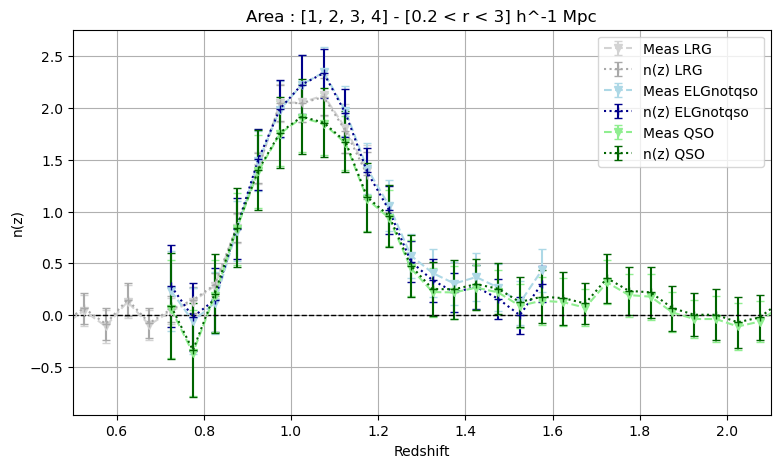

In [7]:
importlib.reload(inference)
importlib.reload(ct)
plt.figure(figsize=(9, 5))
zvals_merge = []
npz_merge = []
npz_err_merge = []
meas_merge = []
meas_err_merge = []

tomo = 3
scale_cut = [0.2, 3]
fr = cf.CorrFileReader(path_dictionary['DESIxHSC'])
stem = 'dr2'
patches = [1,2,3,4]
path_dictionary = {
    'HSC' : ROOT / 'v12_correction' / f'autos_HSC', # with no wpp correction, is unused
    'DESI_NGC' : ROOT / stem / f'autos_NGC',
    'DESI_SGC' : ROOT / stem / f'autos_SGC',
    'DESIxHSC' : ROOT / stem / f'cross',
}
for tracer, color in zip(['LRG', 'ELGnotqso', 'QSO'], ['grey', 'blue', 'green']):
    zbins = fr.get_bins(tracer)
    meas = inference.full_npz_tomo(
        path_dictionary=path_dictionary,
        do_bias_correction=True,
        scale_cuts=scale_cut,
        tomo_bin=tomo,
        tracer=tracer,
        which_patches=patches
    )
    zvals = (zbins[:-1] + zbins[1:]) / 2
    npz, npz_err, wdm, Mag, dMag = ct.solve_magnification(
        meas=meas,
        tracer=tracer,
        tomo_bin=tomo,
        scale_cut=scale_cut,
        zvalues=zvals,
        return_matrices=True
    )
    zvals_merge.append(zvals)
    npz_merge.append(npz)
    npz_err_merge.append(npz_err)
    meas_merge.append(meas[0])
    meas_err_merge.append(meas[1])

    plt.errorbar(zvals, meas[0], yerr=meas[1], fmt='v', color='light' + color, label='Meas ' + tracer, capsize=3, linestyle='--')
    plt.errorbar(zvals, npz, yerr=npz_err, fmt='+', color='dark' + color, label='n(z) ' + tracer, capsize=3, linestyle=':')
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.grid()
plt.xlabel('Redshift')
plt.ylabel('n(z)')
plt.legend()
plt.title(f'Area : {patches} - [{scale_cut[0]} < r < {scale_cut[1]}] h^-1 Mpc')
plt.xlim(0.5, 2.1)

In [8]:
def merge_results(zvals_merge, npz_merge, npz_err_merge, precision=0.0001, co_normalize=False):
    """
    Merge results from different tomographic bins using inverse variance weighting.
    
    Parameters:
    - zvals_merge: list of arrays, each containing redshift values for one tracer/bin
    - npz_merge: list of arrays, each containing values at zvals
    - npz_err_merge: list of arrays, each containing errors at zvals
    
    Returns:
    - zvals: sorted array of unique redshift values
    - npz: merged values at zvals
    - npz_err: corresponding merged errors
    """
    zvals_rounded = [np.round(z / precision) * precision for z in zvals_merge]
    zvals = np.unique(np.concatenate(zvals_rounded))
    npz = np.zeros_like(zvals)
    npz_err = np.zeros_like(zvals)
    weight_sum = np.zeros_like(zvals)
    value_weight_sum = np.zeros_like(zvals)

    npz_merge_rescaled = [np.zeros_like(zvals) for _ in range(len(npz_merge))]
    npz_err_merge_rescaled = [np.zeros_like(zvals) for _ in range(len(npz_err_merge))]
    
    if co_normalize:
        # ensure that all npz_merge arrays are normalized to the same scale
        # by matching on the overlap region
        for i in range(len(npz_merge)):
            if i == 0:
                continue
            # Find the overlap values between zvals_rounded[i] and zvals_rounded[0]
            overlap_vals = np.intersect1d(zvals_rounded[i], zvals_rounded[0])
            if len(overlap_vals) > 0:
                # Get indices of overlap in both arrays
                idx_i = np.nonzero(np.isin(zvals_rounded[i], overlap_vals))[0]
                idx_0 = np.nonzero(np.isin(zvals_rounded[0], overlap_vals))[0]
                # Compute scale factor using only overlapping points
                scale_factor = np.mean(npz_merge[i][idx_i] / npz_merge[0][idx_0])
                npz_merge_rescaled[i] = npz_merge[i] * scale_factor
                npz_err_merge_rescaled[i] = npz_err_merge[i] * scale_factor
    else:
        npz_merge_rescaled = npz_merge
        npz_err_merge_rescaled = npz_err_merge

    for z_i, npz_i, err_i in zip(zvals_rounded, npz_merge_rescaled, npz_err_merge_rescaled):
        indices = np.searchsorted(zvals, z_i)
        weights = 1.0 / (err_i**2)
        value_weight_sum[indices] += npz_i * weights
        weight_sum[indices] += weights

    valid = weight_sum > 0
    assert np.all(valid), "No valid weights found, check input data."
    npz[valid] = value_weight_sum[valid] / weight_sum[valid]
    npz_err[valid] = np.sqrt(1.0 / weight_sum[valid])

    return zvals, npz, npz_err

Text(0.5, 1.0, 'Merged n(z) - [0.2 < r < 3] h^-1 Mpc')

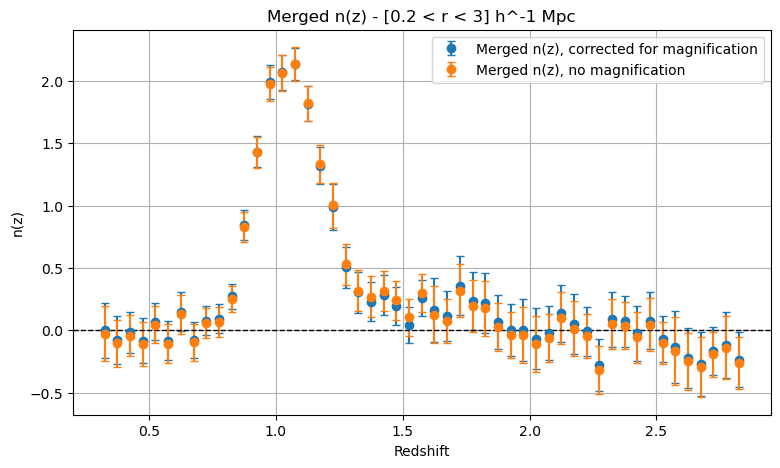

In [9]:
zv, nz, nze = merge_results(zvals_merge, npz_merge, npz_err_merge)
zv2, nz2, nze2 = merge_results(zvals_merge, meas_merge, meas_err_merge)
zvals_arr = np.array(zv)
#zv2, nz2, nze2 = merge_results(zvals_merge, npz_merge, npz_err_merge, co_normalize=True)
#zp, np, npe = 
plt.figure(figsize=(9, 5))
plt.errorbar(zv, nz, yerr=nze, fmt='o', color='C0', label='Merged n(z), corrected for magnification', capsize=3)
plt.errorbar(zv2, nz2, yerr=nze2, fmt='o', color='C1', label='Merged n(z), no magnification', capsize=3)
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.grid()
plt.xlabel('Redshift')
plt.ylabel('n(z)')
plt.legend()
plt.title(f'Merged n(z) - [{scale_cut[0]} < r < {scale_cut[1]}] h^-1 Mpc')

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az
from scipy.interpolate import BSpline
import seaborn as sns

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class BayesianLogSplinePDF:
    def __init__(self, z, nz, nzerr, n_knots=8, degree=3):
        """
        Bayesian log-spline PDF fitting using PyMC
        
        Parameters:
        -----------
        z : array_like - Grid points where PDF is evaluated
        nz : array_like - Observed PDF values (noisy)  
        nzerr : array_like - Uncertainties on PDF values
        n_knots : int - Number of interior knots
        degree : int - B-spline degree
        """
        self.z = np.asarray(z)
        self.nz = np.asarray(nz)
        self.nzerr = np.asarray(nzerr)
        self.n_knots = n_knots
        self.degree = degree
        
        # Create knot vector
        z_min, z_max = self.z.min(), self.z.max()
        z_range = z_max - z_min
        
        # Interior knots (avoid boundaries)
        interior_knots = np.linspace(z_min + 0.05*z_range, z_max - 0.05*z_range, n_knots)
        
        # Full knot vector with repeated boundary knots
        self.knots = np.concatenate([
            [z_min] * (degree + 1),
            interior_knots, 
            [z_max] * (degree + 1)
        ])
        
        self.n_coeffs = len(self.knots) - degree - 1
        print(f"Using {self.n_coeffs} B-spline coefficients")
        
        # Results storage
        self.trace = None
        self.model = None
        
    def create_basis_matrix(self, z_eval=None):
        """Create B-spline basis matrix"""
        if z_eval is None:
            z_eval = self.z
            
        basis_matrix = np.zeros((len(z_eval), self.n_coeffs))
        
        for i in range(self.n_coeffs):
            coeffs = np.zeros(self.n_coeffs)
            coeffs[i] = 1.0
            spline = BSpline(self.knots, coeffs, self.degree)
            basis_matrix[:, i] = spline(z_eval)
            
        return basis_matrix
    
    def fit(self, samples=2000, tune=1000, chains=4, target_accept=0.9):
        """Fit the model using PyMC"""
        
        # Pre-compute basis matrix
        basis_matrix = self.create_basis_matrix()
        
        with pm.Model() as model:
            # Priors on B-spline coefficients
            # Use slightly informative prior to avoid extreme values
            coeffs = pm.Normal('coeffs', mu=0, sigma=1.5, shape=self.n_coeffs)
            
            # Create log-PDF values using basis expansion
            log_pdf_vals = pm.math.dot(basis_matrix, coeffs)
            
            # Convert to PDF: exponentiate and normalize
            pdf_unnorm = pm.math.exp(log_pdf_vals)
            
            # Numerical integration using trapezoidal rule
            dz = self.z[1] - self.z[0]  # Assume uniform grid
            integral = pm.math.sum(pdf_unnorm) * dz - 0.5 * dz * (pdf_unnorm[0] + pdf_unnorm[-1])
            
            # Normalized PDF
            pdf_vals = pdf_unnorm / integral
            pdf = pm.Deterministic('pdf', pdf_vals)
            
            # Log-spline values for diagnostics
            log_pdf = pm.Deterministic('log_pdf', log_pdf_vals)
            
            # Likelihood: observed data with uncertainties
            likelihood = pm.Normal('likelihood', mu=pdf, sigma=self.nzerr, observed=self.nz)
            
            # Sample from posterior
            self.trace = pm.sample(
                samples, 
                tune=tune, 
                chains=chains,
                target_accept=target_accept,
                return_inferencedata=True,
                random_seed=42
            )
            
        self.model = model
        print("Sampling completed!")
        return self.trace
    
    def plot_diagnostics(self, figsize=(15, 12)):
        """Create comprehensive diagnostic plots"""
        if self.trace is None:
            print("No trace available. Run fit() first.")
            return
            
        fig, axes = plt.subplots(3, 3, figsize=figsize)
        axes = axes.flatten()
        
        # 1. Trace plots for first few coefficients
        ax = axes[0]
        for i in range(min(3, self.n_coeffs)):
            trace_vals = self.trace.posterior['coeffs'].sel(coeffs_dim_0=i)
            for chain in range(trace_vals.chain.size):
                ax.plot(trace_vals.isel(chain=chain), alpha=0.7, label=f'coeff_{i}_chain_{chain}' if i==0 else "")
        ax.set_title('Trace plots (first 3 coefficients)')
        ax.set_xlabel('Iteration')
        ax.legend()
        
        # 2. Posterior distributions of coefficients
        ax = axes[1]
        coeff_samples = self.trace.posterior['coeffs'].stack(sample=('chain', 'draw'))
        for i in range(min(5, self.n_coeffs)):
            ax.hist(coeff_samples.sel(coeffs_dim_0=i), alpha=0.6, bins=30, 
                   label=f'coeff_{i}', density=True)
        ax.set_title('Posterior distributions (coefficients)')
        ax.legend()
        
        # 3. R-hat diagnostic
        ax = axes[2]
        rhat = az.rhat(self.trace)['coeffs'].values
        ax.plot(rhat, 'o-')
        ax.axhline(y=1.01, color='r', linestyle='--', label='R̂ = 1.01')
        ax.set_title('R̂ diagnostic')
        ax.set_xlabel('Coefficient index')
        ax.set_ylabel('R̂')
        ax.legend()
        
        # 4. Effective sample size
        ax = axes[3]
        ess = az.ess(self.trace)['coeffs'].values
        ax.plot(ess, 'o-')
        ax.set_title('Effective Sample Size')
        ax.set_xlabel('Coefficient index')
        ax.set_ylabel('ESS')
        
        # 5. Energy plot
        ax = axes[4]
        az.plot_energy(self.trace, ax=ax)
        ax.set_title('Energy Plot')
        
        # 6. Fitted PDF with uncertainty
        ax = axes[5]
        self.plot_fit(ax=ax)
        
        # 7. Residuals
        ax = axes[6]
        self.plot_residuals(ax=ax)
        
        # 8. Log-PDF posterior
        ax = axes[7]
        log_pdf_samples = self.trace.posterior['log_pdf'].stack(sample=('chain', 'draw'))
        log_pdf_mean = log_pdf_samples.mean('sample')
        log_pdf_std = log_pdf_samples.std('sample')
        
        ax.plot(self.z, log_pdf_mean, 'b-', label='Mean log-PDF')
        ax.fill_between(self.z, log_pdf_mean - 2*log_pdf_std, 
                       log_pdf_mean + 2*log_pdf_std, alpha=0.3, label='±2σ')
        ax.set_title('Log-PDF Posterior')
        ax.set_xlabel('z')
        ax.set_ylabel('log(PDF)')
        ax.legend()
        
        # 9. Posterior predictive check
        ax = axes[8]
        self.posterior_predictive_check(ax=ax)
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print("\n" + "="*50)
        print("MCMC DIAGNOSTICS SUMMARY")
        print("="*50)
        print(f"R̂ max: {rhat.max():.4f} (should be < 1.01)")
        print(f"R̂ mean: {rhat.mean():.4f}")
        print(f"ESS min: {ess.min():.0f} (should be > 400)")
        print(f"ESS mean: {ess.mean():.0f}")
        
        if rhat.max() > 1.01:
            print("⚠️  WARNING: Some R̂ values > 1.01. Consider more samples or tuning.")
        if ess.min() < 400:
            print("⚠️  WARNING: Low effective sample size. Consider more samples.")
        
    def plot_fit(self, ax=None, n_samples=100):
        """Plot the fitted PDF with uncertainty bands"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 6))
            
        # Get posterior samples
        pdf_samples = self.trace.posterior['pdf'].stack(sample=('chain', 'draw'))
        
        # Subsample for plotting
        n_total = pdf_samples.sample.size
        idx = np.random.choice(n_total, min(n_samples, n_total), replace=False)
        pdf_subset = pdf_samples.isel(sample=idx)
        
        # Plot uncertainty bands
        pdf_mean = pdf_samples.mean('sample')
        pdf_std = pdf_samples.std('sample')
        pdf_q05 = pdf_samples.quantile(0.05, 'sample')
        pdf_q95 = pdf_samples.quantile(0.95, 'sample')
        
        # Plot data
        ax.errorbar(self.z, self.nz, yerr=self.nzerr, fmt='o', alpha=0.7, 
                   label='Data', color='black', markersize=4)
        
        # Plot fit
        ax.plot(self.z, pdf_mean, 'r-', linewidth=2, label='Posterior mean')
        #ax.fill_between(self.z, pdf_q05, pdf_q95, alpha=0.3, color='red', 
        #               label='90% credible interval')
        ax.fill_between(self.z, pdf_mean - pdf_std, pdf_mean + pdf_std, 
                       alpha=0.5, color='red', label='±1σ')
        ax.axhline(y=0, color='b', linestyle='--')
        ax.set_xlabel('z')
        ax.set_ylabel('PDF')
        ax.set_title('Bayesian Log-Spline PDF Fit')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
    def plot_residuals(self, ax=None):
        """Plot residuals"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 6))
            
        pdf_mean = self.trace.posterior['pdf'].mean(('chain', 'draw'))
        residuals = (self.nz - pdf_mean) / self.nzerr
        
        ax.errorbar(self.z, residuals, yerr=1, fmt='o', alpha=0.7)
        ax.axhline(y=0, color='r', linestyle='--')
        ax.axhline(y=2, color='orange', linestyle=':', alpha=0.7)
        ax.axhline(y=-2, color='orange', linestyle=':', alpha=0.7)
        ax.set_xlabel('z')
        ax.set_ylabel('Standardized residuals')
        ax.set_title('Residuals (data - model)/σ')
        ax.grid(True, alpha=0.3)
        
    def posterior_predictive_check(self, ax=None, n_samples=50):
        """Posterior predictive check"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 6))
            
        # Generate posterior predictive samples
        pdf_samples = self.trace.posterior['pdf'].stack(sample=('chain', 'draw'))
        n_total = pdf_samples.sample.size
        idx = np.random.choice(n_total, min(n_samples, n_total), replace=False)
        
        for i in idx:
            pdf_sample = pdf_samples.isel(sample=i)
            # Add noise according to data uncertainties
            pred_sample = np.random.normal(pdf_sample, self.nzerr)
            ax.plot(self.z, pred_sample, 'b-', alpha=0.1)
            
        # Plot actual data
        ax.errorbar(self.z, self.nz, yerr=self.nzerr, fmt='ro', alpha=0.8, 
                   label='Observed data')
        
        ax.set_xlabel('z')
        ax.set_ylabel('PDF')
        ax.set_title('Posterior Predictive Check')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
    def get_summary(self):
        """Get summary statistics"""
        if self.trace is None:
            print("No trace available. Run fit() first.")
            return None
            
        return az.summary(self.trace, var_names=['coeffs'])

In [23]:

import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az
from scipy.interpolate import BSpline
import seaborn as sns

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class BayesianLogSplinePDF:
    def __init__(self, z, nz, nzerr, n_knots=8, degree=3, edge_penalty=True):
        """
        Bayesian log-spline PDF fitting using PyMC
        
        Parameters:
        -----------
        z : array_like - Grid points where PDF is evaluated
        nz : array_like - Observed PDF values (noisy)  
        nzerr : array_like - Uncertainties on PDF values
        n_knots : int - Number of interior knots
        degree : int - B-spline degree
        edge_penalty : bool - Apply penalty to encourage negative edges
        """
        self.z = np.asarray(z)
        self.nz = np.asarray(nz)
        self.nzerr = np.asarray(nzerr)
        self.n_knots = n_knots
        self.degree = degree
        self.edge_penalty = edge_penalty
        
        # Create knot vector
        z_min, z_max = self.z.min(), self.z.max()
        z_range = z_max - z_min
        
        # Interior knots (extend slightly beyond data range for better edge behavior)
        z_pad = 0.1 * z_range
        z_extended_min = z_min - z_pad
        z_extended_max = z_max + z_pad
        interior_knots = np.linspace(z_extended_min, z_extended_max, n_knots)
        
        # Full knot vector with repeated boundary knots (extended range)
        self.knots = np.concatenate([
            [z_extended_min] * (degree + 1),
            interior_knots, 
            [z_extended_max] * (degree + 1)
        ])
        
        self.n_coeffs = len(self.knots) - degree - 1
        print(f"Using {self.n_coeffs} B-spline coefficients")
        
        # Results storage
        self.trace = None
        self.model = None
        
    def create_basis_matrix(self, z_eval=None):
        """Create B-spline basis matrix"""
        if z_eval is None:
            z_eval = self.z
            
        basis_matrix = np.zeros((len(z_eval), self.n_coeffs))
        
        for i in range(self.n_coeffs):
            coeffs = np.zeros(self.n_coeffs)
            coeffs[i] = 1.0
            spline = BSpline(self.knots, coeffs, self.degree)
            basis_matrix[:, i] = spline(z_eval)
            
        return basis_matrix
    
    def fit(self, samples=2000, tune=1000, chains=4, target_accept=0.9):
        """Fit the model using PyMC"""
        
        # Pre-compute basis matrix
        basis_matrix = self.create_basis_matrix()
        
        with pm.Model() as model:
            # Priors on B-spline coefficients with optional edge regularization
            if self.edge_penalty:
                # Different priors for edge vs interior coefficients
                n_edge = 2  # number of edge coeffs on each side
                
                # Edge coefficients: encouraged to be negative (low PDF values)
                edge_coeffs_left = pm.Normal('edge_coeffs_left', mu=-2, sigma=1, shape=n_edge)
                edge_coeffs_right = pm.Normal('edge_coeffs_right', mu=-2, sigma=1, shape=n_edge)
                
                # Interior coefficients: less constrained
                interior_coeffs = pm.Normal('interior_coeffs', mu=0, sigma=2, 
                                          shape=self.n_coeffs - 2*n_edge)
                
                # Combine all coefficients
                coeffs = pt.concatenate([edge_coeffs_left, interior_coeffs, edge_coeffs_right])
            else:
                coeffs = pm.Normal('coeffs', mu=0, sigma=1.5, shape=self.n_coeffs)
            
            # Store coefficients for diagnostics
            coeffs_combined = pm.Deterministic('coeffs', coeffs)
            
            # Create log-PDF values using basis expansion
            log_pdf_vals = pm.math.dot(basis_matrix, coeffs_combined)
            
            # Convert to PDF: exponentiate and normalize
            pdf_unnorm = pm.math.exp(log_pdf_vals)
            
            # Numerical integration using trapezoidal rule
            dz = self.z[1] - self.z[0]  # Assume uniform grid
            integral = pm.math.sum(pdf_unnorm) * dz - 0.5 * dz * (pdf_unnorm[0] + pdf_unnorm[-1])
            
            # Normalized PDF
            pdf_vals = pdf_unnorm / integral
            pdf = pm.Deterministic('pdf', pdf_vals)
            
            # Log-spline values for diagnostics
            log_pdf = pm.Deterministic('log_pdf', log_pdf_vals)
            
            # Likelihood: observed data with uncertainties
            likelihood = pm.Normal('likelihood', mu=pdf, sigma=self.nzerr, observed=self.nz)
            
            # Sample from posterior
            self.trace = pm.sample(
                samples, 
                tune=tune, 
                chains=chains,
                target_accept=target_accept,
                return_inferencedata=True,
                random_seed=42
            )
            
        self.model = model
        print("Sampling completed!")
        return self.trace
    
    def plot_diagnostics(self, figsize=(15, 12)):
        """Create comprehensive diagnostic plots"""
        if self.trace is None:
            print("No trace available. Run fit() first.")
            return
            
        fig, axes = plt.subplots(3, 3, figsize=figsize)
        axes = axes.flatten()
        
        # 1. Trace plots for first few coefficients
        ax = axes[0]
        for i in range(min(3, self.n_coeffs)):
            trace_vals = self.trace.posterior['coeffs'].sel(coeffs_dim_0=i)
            for chain in range(trace_vals.chain.size):
                ax.plot(trace_vals.isel(chain=chain), alpha=0.7, label=f'coeff_{i}_chain_{chain}' if i==0 else "")
        ax.set_title('Trace plots (first 3 coefficients)')
        ax.set_xlabel('Iteration')
        ax.legend()
        
        # 2. Posterior distributions of coefficients
        ax = axes[1]
        coeff_samples = self.trace.posterior['coeffs'].stack(sample=('chain', 'draw'))
        for i in range(min(5, self.n_coeffs)):
            ax.hist(coeff_samples.sel(coeffs_dim_0=i), alpha=0.6, bins=30, 
                   label=f'coeff_{i}', density=True)
        ax.set_title('Posterior distributions (coefficients)')
        ax.legend()
        
        # 3. R-hat diagnostic
        ax = axes[2]
        rhat = az.rhat(self.trace)['coeffs'].values
        ax.plot(rhat, 'o-')
        ax.axhline(y=1.01, color='r', linestyle='--', label='R̂ = 1.01')
        ax.set_title('R̂ diagnostic')
        ax.set_xlabel('Coefficient index')
        ax.set_ylabel('R̂')
        ax.legend()
        
        # 4. Effective sample size
        ax = axes[3]
        ess = az.ess(self.trace)['coeffs'].values
        ax.plot(ess, 'o-')
        ax.set_title('Effective Sample Size')
        ax.set_xlabel('Coefficient index')
        ax.set_ylabel('ESS')
        
        # 5. Energy plot
        ax = axes[4]
        az.plot_energy(self.trace, ax=ax)
        ax.set_title('Energy Plot')
        
        # 6. Fitted PDF with uncertainty
        ax = axes[5]
        self.plot_fit(ax=ax)
        
        # 7. Residuals
        ax = axes[6]
        self.plot_residuals(ax=ax)
        
        # 8. Log-PDF posterior
        ax = axes[7]
        log_pdf_samples = self.trace.posterior['log_pdf'].stack(sample=('chain', 'draw'))
        log_pdf_mean = log_pdf_samples.mean('sample')
        log_pdf_std = log_pdf_samples.std('sample')
        
        ax.plot(self.z, log_pdf_mean, 'b-', label='Mean log-PDF')
        ax.fill_between(self.z, log_pdf_mean - 2*log_pdf_std, 
                       log_pdf_mean + 2*log_pdf_std, alpha=0.3, label='±2σ')
        ax.set_title('Log-PDF Posterior')
        ax.set_xlabel('z')
        ax.set_ylabel('log(PDF)')
        ax.legend()
        
        # 9. Posterior predictive check
        ax = axes[8]
        self.posterior_predictive_check(ax=ax)
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print("\n" + "="*50)
        print("MCMC DIAGNOSTICS SUMMARY")
        print("="*50)
        print(f"R̂ max: {rhat.max():.4f} (should be < 1.01)")
        print(f"R̂ mean: {rhat.mean():.4f}")
        print(f"ESS min: {ess.min():.0f} (should be > 400)")
        print(f"ESS mean: {ess.mean():.0f}")
        
        if rhat.max() > 1.01:
            print("⚠️  WARNING: Some R̂ values > 1.01. Consider more samples or tuning.")
        if ess.min() < 400:
            print("⚠️  WARNING: Low effective sample size. Consider more samples.")
        
    def plot_fit(self, ax=None, n_samples=100):
        """Plot the fitted PDF with uncertainty bands"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 6))
            
        # Get posterior samples
        pdf_samples = self.trace.posterior['pdf'].stack(sample=('chain', 'draw'))
        
        # Subsample for plotting
        n_total = pdf_samples.sample.size
        idx = np.random.choice(n_total, min(n_samples, n_total), replace=False)
        pdf_subset = pdf_samples.isel(sample=idx)
        
        # Plot uncertainty bands
        pdf_mean = pdf_samples.mean('sample')
        pdf_std = pdf_samples.std('sample')
        pdf_q05 = pdf_samples.quantile(0.05, 'sample')
        pdf_q95 = pdf_samples.quantile(0.95, 'sample')
        
        # Plot data
        ax.errorbar(self.z, self.nz, yerr=self.nzerr, fmt='o', alpha=0.7, 
                   label='Data', color='black', markersize=4)
        
        # Plot fit
        ax.plot(self.z, pdf_mean, 'r-', linewidth=2, label='Posterior mean')
        ax.fill_between(self.z, pdf_q05, pdf_q95, alpha=0.3, color='red', 
                       label='90% credible interval')
        ax.fill_between(self.z, pdf_mean - pdf_std, pdf_mean + pdf_std, 
                       alpha=0.5, color='red', label='±1σ')
        
        ax.set_xlabel('z')
        ax.set_ylabel('PDF')
        ax.set_title('Bayesian Log-Spline PDF Fit')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
    def plot_residuals(self, ax=None):
        """Plot residuals"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 6))
            
        pdf_mean = self.trace.posterior['pdf'].mean(('chain', 'draw'))
        residuals = (self.nz - pdf_mean) / self.nzerr
        
        ax.errorbar(self.z, residuals, yerr=1, fmt='o', alpha=0.7)
        ax.axhline(y=0, color='r', linestyle='--')
        ax.axhline(y=2, color='orange', linestyle=':', alpha=0.7)
        ax.axhline(y=-2, color='orange', linestyle=':', alpha=0.7)
        ax.set_xlabel('z')
        ax.set_ylabel('Standardized residuals')
        ax.set_title('Residuals (data - model)/σ')
        ax.grid(True, alpha=0.3)
        
    def posterior_predictive_check(self, ax=None, n_samples=50):
        """Posterior predictive check"""
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 6))
            
        # Generate posterior predictive samples
        pdf_samples = self.trace.posterior['pdf'].stack(sample=('chain', 'draw'))
        n_total = pdf_samples.sample.size
        idx = np.random.choice(n_total, min(n_samples, n_total), replace=False)
        
        for i in idx:
            pdf_sample = pdf_samples.isel(sample=i)
            # Add noise according to data uncertainties
            pred_sample = np.random.normal(pdf_sample, self.nzerr)
            ax.plot(self.z, pred_sample, 'b-', alpha=0.1)
            
        # Plot actual data
        ax.errorbar(self.z, self.nz, yerr=self.nzerr, fmt='ro', alpha=0.8, 
                   label='Observed data')
        
        ax.set_xlabel('z')
        ax.set_ylabel('PDF')
        ax.set_title('Posterior Predictive Check')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
    def get_summary(self):
        """Get summary statistics"""
        if self.trace is None:
            print("No trace available. Run fit() first.")
            return None
            
        return az.summary(self.trace, var_names=['coeffs'])

In [24]:
model = BayesianLogSplinePDF(zv, nz, nze, n_knots=15)
trace = model.fit(samples=4000, tune=1000, chains=4, target_accept=0.99) 

Using 19 B-spline coefficients


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [edge_coeffs_left, edge_coeffs_right, interior_coeffs]
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [edge_coeffs_left, edge_coeffs_right, interior_coeffs]


Output()

Sampling 4 chains for 1_000 tune and 4_000 draw iterations (4_000 + 16_000 draws total) took 21 seconds.


Sampling completed!


/tmp/ipykernel_169938/290666923.py:212: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/global/cfs/projectdirs/desi/users/jchdj/conda/envs/pymc-env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/global/cfs/projectdirs/desi/users/jchdj/conda/envs/pymc-env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


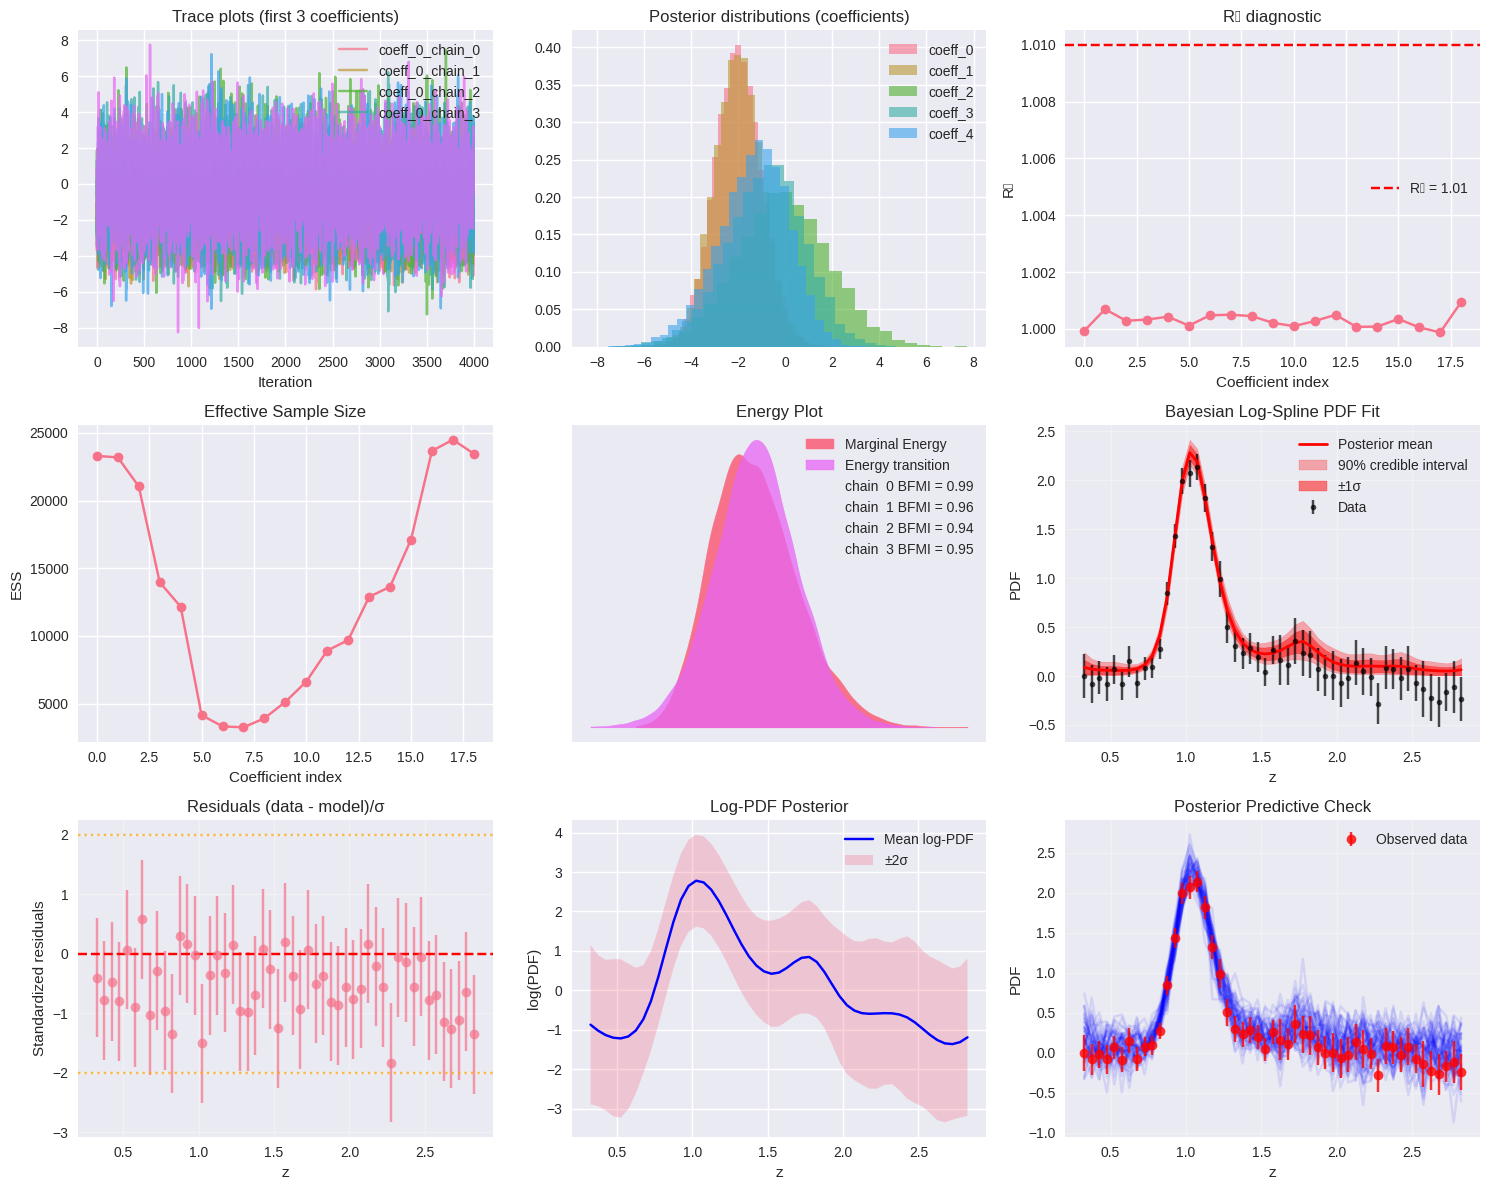


MCMC DIAGNOSTICS SUMMARY
R̂ max: 1.0009 (should be < 1.01)
R̂ mean: 1.0003
ESS min: 3243 (should be > 400)
ESS mean: 13361


In [25]:
model.plot_diagnostics()

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az
from scipy.interpolate import BSpline
import seaborn as sns

class AdaptiveKnotLogSplinePDF:
    def __init__(self, z, nz, nzerr, n_knots=8, degree=3, adaptive_knots=True, 
                 knot_prior_strength=1.0):
        """
        Bayesian log-spline PDF with adaptive knot placement
        
        Parameters:
        -----------
        z : array_like - Grid points where PDF is evaluated
        nz : array_like - Observed PDF values (noisy)  
        nzerr : array_like - Uncertainties on PDF values
        n_knots : int - Number of interior knots
        degree : int - B-spline degree
        adaptive_knots : bool - Whether to treat knot positions as parameters
        knot_prior_strength : float - Controls how much knots can move from uniform
        """
        self.z = np.asarray(z)
        self.nz = np.asarray(nz)
        self.nzerr = np.asarray(nzerr)
        self.n_knots = n_knots
        self.degree = degree
        self.adaptive_knots = adaptive_knots
        self.knot_prior_strength = knot_prior_strength
        
        # Data range with padding
        self.z_min, self.z_max = self.z.min(), self.z.max()
        self.z_range = self.z_max - self.z_min
        self.z_pad = 0.1 * self.z_range
        
        # Initial uniform knot placement (used as prior mean)
        self.uniform_knots = np.linspace(
            self.z_min - self.z_pad, 
            self.z_max + self.z_pad, 
            n_knots
        )
        
        # Results storage
        self.trace = None
        self.model = None
        
    def create_full_knots(self, interior_knots):
        """Create full knot vector with boundary repetitions"""
        return pt.concatenate([
            pt.repeat(interior_knots[0], self.degree + 1),
            interior_knots,
            pt.repeat(interior_knots[-1], self.degree + 1)
        ])
    
    def create_basis_matrix_adaptive(self, z_eval, knots_full):
        """Create B-spline basis matrix with adaptive knots (PyTensor compatible)"""
        n_coeffs = knots_full.shape[0] - self.degree - 1
        
        def single_basis(i, z_pt, knots_pt):
            """Compute single B-spline basis function using Cox-de Boor formula"""
            def cox_de_boor(z, i, p, knots):
                if p == 0:
                    # Base case: piecewise constant
                    return pt.switch(
                        pt.and_(z >= knots[i], z < knots[i+1]),
                        1.0, 0.0
                    )
                else:
                    # Recursive case
                    left_denom = knots[i+p] - knots[i]
                    right_denom = knots[i+p+1] - knots[i+1]
                    
                    left_term = pt.switch(
                        pt.abs(left_denom) < 1e-10,
                        0.0,
                        (z - knots[i]) / left_denom * cox_de_boor(z, i, p-1, knots)
                    )
                    
                    right_term = pt.switch(
                        pt.abs(right_denom) < 1e-10,
                        0.0,
                        (knots[i+p+1] - z) / right_denom * cox_de_boor(z, i+1, p-1, knots)
                    )
                    
                    return left_term + right_term
            
            return cox_de_boor(z_pt, i, self.degree, knots_pt)
        
        # Create basis matrix
        basis_values = []
        for i in range(n_coeffs):
            basis_i = pt.stack([single_basis(i, z_pt, knots_full) for z_pt in z_eval])
            basis_values.append(basis_i)
        
        return pt.stack(basis_values, axis=1)
    
    def fit_adaptive(self, samples=2000, tune=1000, chains=4, target_accept=0.8):
        """Fit model with adaptive knot placement"""
        
        with pm.Model() as model:
            if self.adaptive_knots:
                # APPROACH 1: Ordered knot positions with soft constraints
                # Use ordered transform to ensure knots remain ordered
                knot_raw = pm.Normal('knot_raw', mu=0, sigma=1, shape=self.n_knots)
                
                # Transform to ordered knots in data range
                knot_range = self.z_max + 2*self.z_pad - (self.z_min - self.z_pad)
                knot_cumsum = pt.cumsum(pt.exp(knot_raw))
                knot_cumsum_norm = knot_cumsum / knot_cumsum[-1] * knot_range
                interior_knots = knot_cumsum_norm + (self.z_min - self.z_pad)
                
                # Add soft prior to keep knots near uniform spacing
                uniform_spacing = (self.z_max + self.z_pad - (self.z_min - self.z_pad)) / (self.n_knots - 1)
                expected_positions = (self.z_min - self.z_pad) + pt.arange(self.n_knots) * uniform_spacing
                
                knot_prior = pm.Normal('knot_prior', 
                                     mu=0, sigma=self.knot_prior_strength,
                                     observed=(interior_knots - expected_positions) / uniform_spacing)
                
            else:
                # Fixed uniform knots
                interior_knots = pt.as_tensor_variable(self.uniform_knots)
            
            # Create full knot vector
            knots_full = self.create_full_knots(interior_knots)
            n_coeffs = knots_full.shape[0] - self.degree - 1
            
            # Priors on coefficients (with edge regularization)
            n_edge = 2
            edge_coeffs_left = pm.Normal('edge_coeffs_left', mu=-2, sigma=1, shape=n_edge)
            edge_coeffs_right = pm.Normal('edge_coeffs_right', mu=-2, sigma=1, shape=n_edge)
            interior_coeffs = pm.Normal('interior_coeffs', mu=0, sigma=2, 
                                      shape=n_coeffs - 2*n_edge)
            coeffs = pt.concatenate([edge_coeffs_left, interior_coeffs, edge_coeffs_right])
            
            # Create basis matrix with adaptive knots
            basis_matrix = self.create_basis_matrix_adaptive(self.z, knots_full)
            
            # Create log-PDF
            log_pdf_vals = pt.dot(basis_matrix, coeffs)
            
            # Convert to PDF
            pdf_unnorm = pt.exp(log_pdf_vals)
            dz = self.z[1] - self.z[0]
            integral = pt.sum(pdf_unnorm) * dz - 0.5 * dz * (pdf_unnorm[0] + pdf_unnorm[-1])
            pdf_vals = pdf_unnorm / integral
            
            # Store deterministics
            pdf = pm.Deterministic('pdf', pdf_vals)
            log_pdf = pm.Deterministic('log_pdf', log_pdf_vals)
            if self.adaptive_knots:
                knots_det = pm.Deterministic('knots', interior_knots)
            
            # Likelihood
            likelihood = pm.Normal('likelihood', mu=pdf, sigma=self.nzerr, observed=self.nz)
            
            # Sample
            self.trace = pm.sample(
                samples, tune=tune, chains=chains,
                target_accept=target_accept,
                return_inferencedata=True,
                random_seed=42
            )
            
        self.model = model
        return self.trace
    
    def plot_knot_evolution(self, figsize=(12, 8)):
        """Plot how knots evolved during sampling"""
        if not self.adaptive_knots or self.trace is None:
            print("No adaptive knots or trace available")
            return
            
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        
        # Knot positions over iterations
        ax = axes[0, 0]
        knots_samples = self.trace.posterior['knots']
        for i in range(self.n_knots):
            for chain in range(knots_samples.chain.size):
                ax.plot(knots_samples.sel(knots_dim_0=i, chain=chain), 
                       alpha=0.7, label=f'knot_{i}' if chain == 0 else "")
        ax.set_title('Knot Position Traces')
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Knot Position')
        if self.n_knots <= 8:
            ax.legend()
        
        # Final knot positions
        ax = axes[0, 1]
        knots_final = knots_samples.stack(sample=('chain', 'draw'))
        knots_mean = knots_final.mean('sample')
        knots_std = knots_final.std('sample')
        
        ax.errorbar(range(self.n_knots), knots_mean, yerr=knots_std, 
                   fmt='ro-', label='Posterior knots')
        ax.plot(range(self.n_knots), self.uniform_knots, 'b^--', 
               label='Uniform knots', alpha=0.7)
        ax.set_title('Final Knot Positions')
        ax.set_xlabel('Knot Index')
        ax.set_ylabel('Position')
        ax.legend()
        
        # Knot density (how much they moved)
        ax = axes[1, 0]
        knot_movements = np.abs(knots_mean - self.uniform_knots)
        ax.bar(range(self.n_knots), knot_movements)
        ax.set_title('Knot Movement from Uniform')
        ax.set_xlabel('Knot Index')
        ax.set_ylabel('|Movement|')
        
        # Data overlay with knots
        ax = axes[1, 1]
        ax.errorbar(self.z, self.nz, yerr=self.nzerr, fmt='ko', alpha=0.6, 
                   label='Data')
        
        # Plot posterior PDF
        pdf_samples = self.trace.posterior['pdf'].stack(sample=('chain', 'draw'))
        pdf_mean = pdf_samples.mean('sample')
        ax.plot(self.z, pdf_mean, 'r-', linewidth=2, label='Fitted PDF')
        
        # Show knot positions
        for i, knot_pos in enumerate(knots_mean):
            if self.z.min() <= knot_pos <= self.z.max():
                ax.axvline(knot_pos, color='red', alpha=0.3, linestyle='--')
        
        # Show uniform knots for comparison
        for i, knot_pos in enumerate(self.uniform_knots):
            if self.z.min() <= knot_pos <= self.z.max():
                ax.axvline(knot_pos, color='blue', alpha=0.2, linestyle=':')
        
        ax.set_title('Data with Adaptive Knots')
        ax.legend()
        
        plt.tight_layout()
        plt.show()
        
    def compare_fits(self, figsize=(15, 5)):
        """Compare adaptive vs fixed knot fits"""
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        
        # Fit fixed knot version for comparison
        fixed_model = AdaptiveKnotLogSplinePDF(
            self.z, self.nz, self.nzerr, self.n_knots, 
            adaptive_knots=False
        )
        
        print("Fitting fixed knot model...")
        fixed_trace = fixed_model.fit_adaptive(samples=1000, tune=500, chains=2)
        
        # Plot comparisons
        pdf_adaptive = self.trace.posterior['pdf'].mean(('chain', 'draw'))
        pdf_fixed = fixed_trace.posterior['pdf'].mean(('chain', 'draw'))
        
        # Data and fits
        ax = axes[0]
        ax.errorbar(self.z, self.nz, yerr=self.nzerr, fmt='ko', alpha=0.6, 
                   label='Data')
        ax.plot(self.z, pdf_adaptive, 'r-', linewidth=2, label='Adaptive knots')
        ax.plot(self.z, pdf_fixed, 'b--', linewidth=2, label='Fixed knots')
        ax.set_title('Model Comparison')
        ax.legend()
        
        # Residuals
        ax = axes[1]
        resid_adaptive = (self.nz - pdf_adaptive) / self.nzerr
        resid_fixed = (self.nz - pdf_fixed) / self.nzerr
        
        ax.plot(self.z, resid_adaptive, 'ro-', alpha=0.7, label='Adaptive')
        ax.plot(self.z, resid_fixed, 'b^--', alpha=0.7, label='Fixed')
        ax.axhline(0, color='k', linestyle='-', alpha=0.3)
        ax.set_title('Standardized Residuals')
        ax.legend()
        
        # Model comparison metrics
        ax = axes[2]
        
        # Compute WAIC for both models
        waic_adaptive = az.waic(self.trace)
        waic_fixed = az.waic(fixed_trace)
        
        metrics = ['WAIC', 'Chi-squared']
        adaptive_vals = [waic_adaptive.waic, np.sum(resid_adaptive**2)]
        fixed_vals = [waic_fixed.waic, np.sum(resid_fixed**2)]
        
        x = np.arange(len(metrics))
        width = 0.35
        
        ax.bar(x - width/2, adaptive_vals, width, label='Adaptive', alpha=0.7)
        ax.bar(x + width/2, fixed_vals, width, label='Fixed', alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        ax.set_title('Model Comparison')
        ax.legend()
        
        plt.tight_layout()
        plt.show()
        
        print(f"\nModel Comparison:")
        print(f"Adaptive WAIC: {waic_adaptive.waic:.2f}")
        print(f"Fixed WAIC: {waic_fixed.waic:.2f}")
        print(f"ΔWAIC: {waic_adaptive.waic - waic_fixed.waic:.2f}")

In [30]:
import pandas as pd
df = pd.DataFrame({'z': zv, 'nz': nz, 'nze': nze})
df.to_parquet('nz.parquet', index=False)

In [29]:
model = AdaptiveKnotLogSplinePDF(zv, nz, nze)
trace = model.fit_adaptive(samples=4000, tune=1000, chains=4, target_accept=0.95)
model.plot_knot_evolution()

TypeError: Variables that depend on other nodes cannot be used for observed data.The data variable was: True_div.0

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [coefs]
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [coefs]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 4 seconds.


[[0.00127973 0.00486034 0.00877044 ... 0.00711289 0.0144     0.00889699]
 [0.13575959 0.03088725 0.12317343 ... 0.32459382 0.18185617 0.30247399]
 [0.24949398 0.00156514 0.15854511 ... 0.17410927 0.09036591 0.16007303]
 ...
 [0.1517743  0.05169349 0.04438956 ... 0.07617061 0.32556284 0.01166128]
 [0.00217989 0.07253088 0.42136848 ... 0.1137411  0.15837859 0.03536078]
 [0.24883142 0.0240786  0.02040057 ... 0.06280024 0.38778191 0.00608635]]


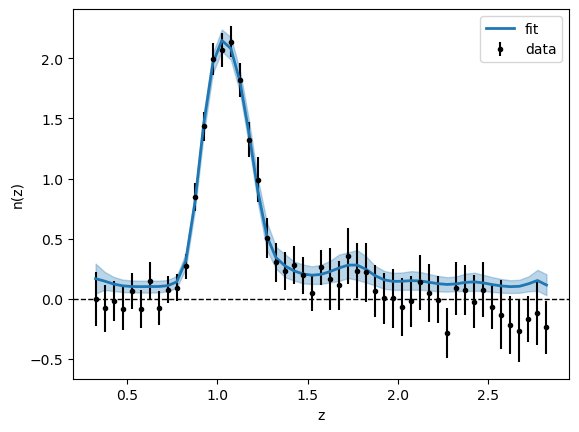

In [90]:
import matplotlib.pyplot as plt
from patsy import dmatrix
import numpy as np
import pymc as pm

# Create a dense fixed knot grid (say 25 knots)
n_knots = 25
knot_locs = np.linspace(np.min(zvals_arr), np.max(zvals_arr), n_knots)

# Use cubic B-splines (degree=3)
spline_basis = dmatrix(
    "bs(x, knots=knots[1:-1], degree=3, include_intercept=True)",
    {"x": zvals_arr, "knots": knot_locs},
    return_type='dataframe'
).values

with pm.Model() as model:
    coefs = pm.HalfNormal("coefs", sigma=100, shape=spline_basis.shape[1])
    mu = pm.math.dot(spline_basis, coefs)
    obs = pm.Normal("obs", mu=mu, sigma=nze, observed=nz)
    trace = pm.sample(2000, tune=1000, target_accept=0.95, return_inferencedata=True)

# Ensure mu_post shape matches spline_basis for matrix multiplication
coefs = trace.posterior["coefs"]
if "draw" in coefs.dims:
    # coefs shape: (chain, draw, n_basis) or (draw, n_basis)
    # Reshape to (n_basis, n_samples)
    arr = coefs.values
    if arr.ndim == 3:
        arr = arr.reshape(-1, arr.shape[-1])  # (n_samples, n_basis)
        mu_post = arr.T  # (n_basis, n_samples)
    elif arr.ndim == 2:
        mu_post = arr.T  # (n_basis, n_samples)
    else:
        mu_post = arr  # fallback
else:
    stacked = coefs.stack(draw=("chain", "draw"))
    mu_post = stacked.values.T  # (n_basis, n_samples)
print(mu_post)
nz_fit = spline_basis @ mu_post

# Median and credible intervals
nz_median = np.mean(nz_fit, axis=1)
nz_lower = np.percentile(nz_fit, 16, axis=1)
nz_upper = np.percentile(nz_fit, 84, axis=1)

plt.errorbar(zvals_arr, nz, yerr=nze, fmt=".k", label="data")
plt.plot(zvals_arr, nz_median, label="fit", lw=2)
plt.fill_between(zvals_arr, nz_lower, nz_upper, color='C0', alpha=0.3)
plt.legend()
plt.xlabel("z")
plt.ylabel("n(z)")
plt.axhline(0, color='k', linestyle='--', linewidth=1)

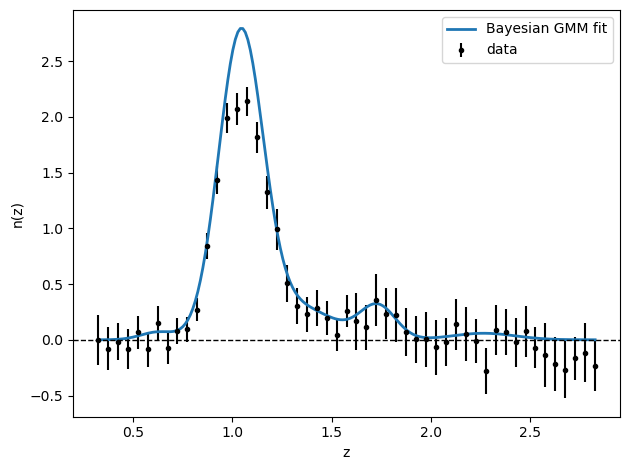

In [76]:
from sklearn.mixture import BayesianGaussianMixture

# Sample pseudo-data using histogram + noise
n_samples = 10000
prob_weights = np.maximum(nz, 0)
prob_weights /= prob_weights.sum()
z_samples = np.random.choice(zvals_arr, size=n_samples, p=prob_weights)

# Fit Bayesian GMM
bgmm = BayesianGaussianMixture(
    n_components=5,                # upper limit on components
    weight_concentration_prior_type='dirichlet_process',
    weight_concentration_prior=0.1,
    covariance_type='full',
    max_iter=1000
)
z_samples = z_samples.reshape(-1, 1)
bgmm.fit(z_samples)

# Predict PDF on grid
zgrid = np.linspace(zvals_arr.min(), zvals_arr.max(), 200)
pdf = np.exp(bgmm.score_samples(zgrid.reshape(-1, 1)))  # log-density → density

# Plot
plt.errorbar(zvals_arr, nz, yerr=nze, fmt='.k', label='data')
plt.plot(zgrid, pdf, label='Bayesian GMM fit', lw=2)
plt.xlabel('z')
plt.ylabel('n(z)')
plt.axhline(0, color='k', linestyle='--', lw=1)
plt.legend()
plt.tight_layout()
plt.show()
